## install required packages and libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

# Phase1: Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('dataset/PRSA_data_2010.1.1-2014.12.31.csv')

print(f"Total samples (rows): {df.shape[0]:,}")
print(f"Total features (columns): {df.shape[1]}")
print(f"Temporal frequency: Hourly")
print(f"Time period: {df['year'].min()} to {df['year'].max()}")
print(f"Approximate days covered: {len(df)/24:.0f} days")
print(f"Memory usage: {df.memory_usage(deep=True).sum()/1024**2:.2f} MB")

Total samples (rows): 43,824
Total features (columns): 13
Temporal frequency: Hourly
Time period: 2010 to 2014
Approximate days covered: 1826 days
Memory usage: 6.14 MB


In [4]:
df.isnull().sum()

# print('\n', (df.isnull().sum() / len(df)) * 100)

No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64

In [5]:
print(df.info())

missing_df = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
}).sort_values('Missing_Count', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0])

print(f"\nTotal missing values in dataset: {df.isnull().sum().sum():,}")
print(f"Overall missing percentage: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")

print("Missing Value Pattern Analysis:")
missing_pattern = df.isnull().any(axis=1)
print(f"Samples with any missing value: {missing_pattern.sum():,} ({missing_pattern.sum()/len(df)*100:.2f}%)")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB
None
Missing Values Summary:
       Missing_Count  Missing_Percentage
pm2.5           2067            4.716594

Total missing values in dataset: 2,067
Overall missing percentage: 0.36%
Missing Value Pattern Analysis:
Samples with any missing value: 2,067 (4.72%)


In [6]:
print("Descriptive statistics")
print(df.describe())

print('\n')
print("The target variable (pm2.5) statistics")
print(df['pm2.5'].describe())
print(f"\nSkewness: {df['pm2.5'].skew():.3f}")
print(f"Kurtosis: {df['pm2.5'].kurtosis():.3f}")
print(f"IQR: {df['pm2.5'].quantile(0.75) - df['pm2.5'].quantile(0.25):.2f}")

print('\n')
print("Categorical Data Analysis")
print(f"\nWind Direction (cbwd) distribution:")
print(df['cbwd'].value_counts())
print(f"\nUnique values: {df['cbwd'].nunique()}")

print('\n')
print("Correlation Analysis")
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_with_target = df[numeric_cols].corr()['pm2.5'].sort_values(ascending=False)
print("\nCorrelation with pm2.5:")
print(correlation_with_target)


Descriptive statistics
                 No          year         month           day          hour  \
count  43824.000000  43824.000000  43824.000000  43824.000000  43824.000000   
mean   21912.500000   2012.000000      6.523549     15.727820     11.500000   
std    12651.043435      1.413842      3.448572      8.799425      6.922266   
min        1.000000   2010.000000      1.000000      1.000000      0.000000   
25%    10956.750000   2011.000000      4.000000      8.000000      5.750000   
50%    21912.500000   2012.000000      7.000000     16.000000     11.500000   
75%    32868.250000   2013.000000     10.000000     23.000000     17.250000   
max    43824.000000   2014.000000     12.000000     31.000000     23.000000   

              pm2.5          DEWP          TEMP          PRES           Iws  \
count  41757.000000  43824.000000  43824.000000  43824.000000  43824.000000   
mean      98.613215      1.817246     12.448521   1016.447654     23.889140   
std       92.050387     14.4

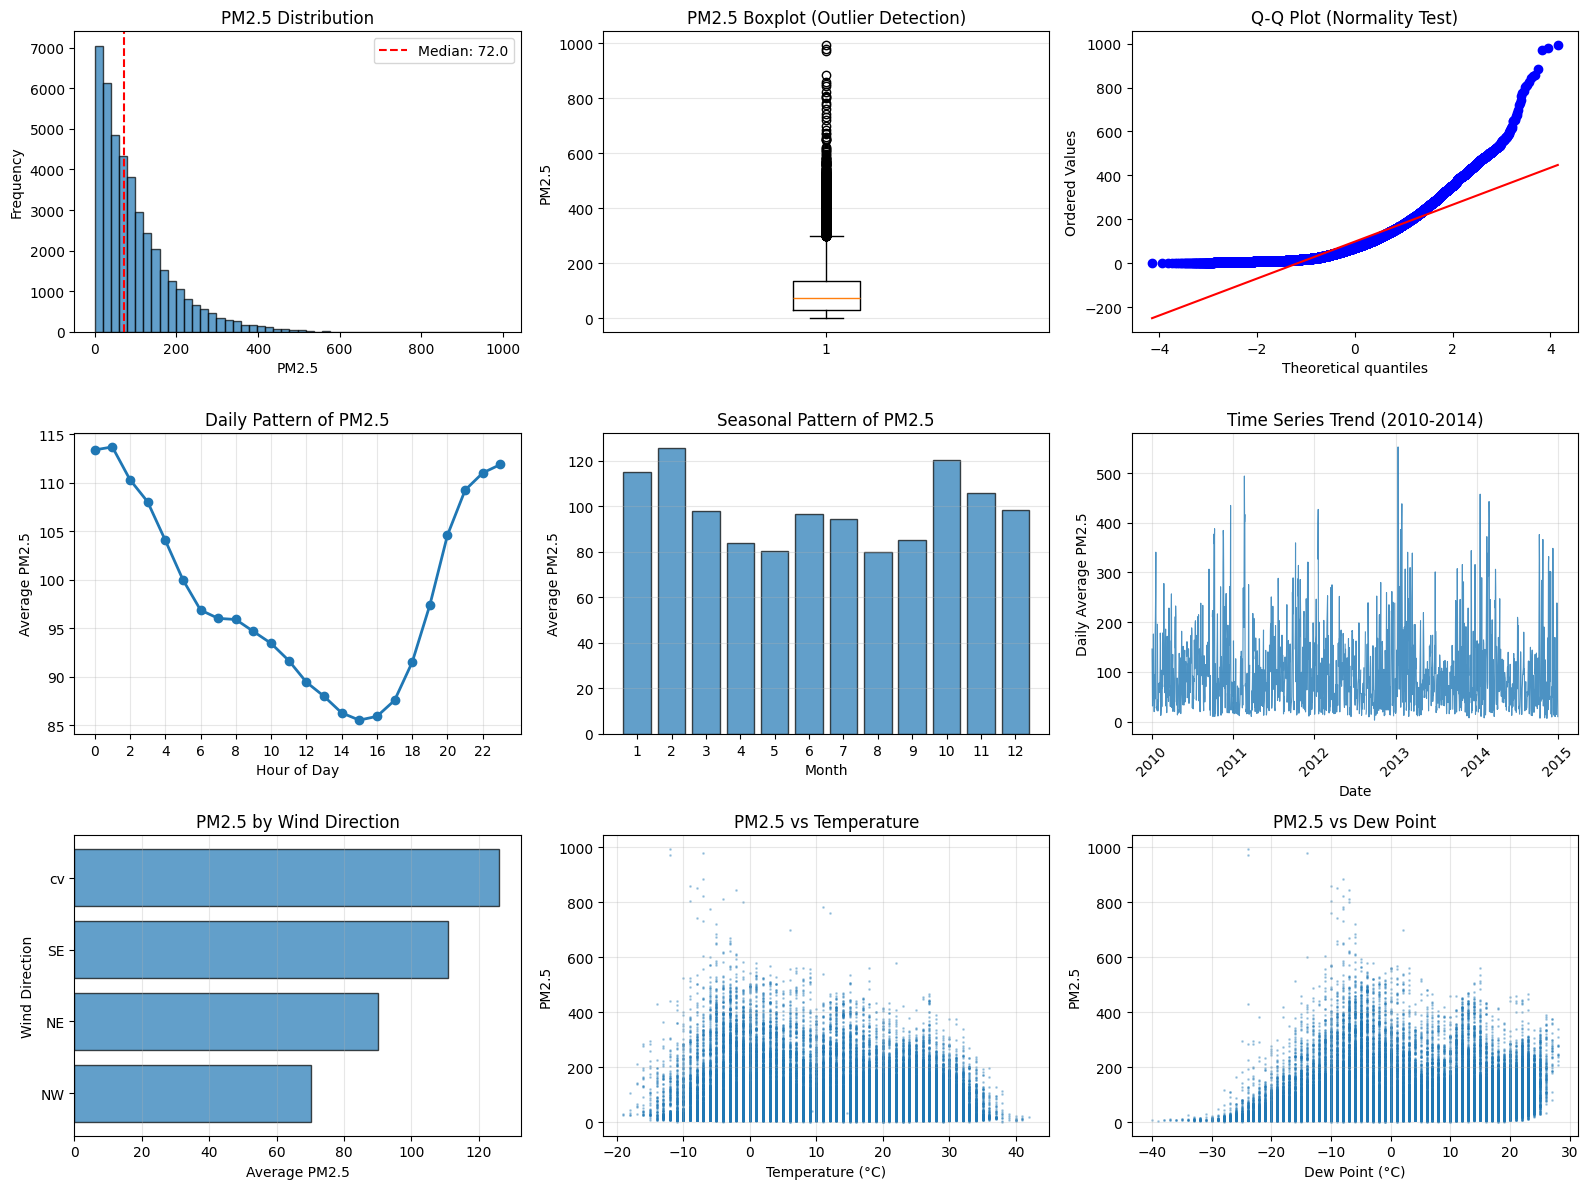

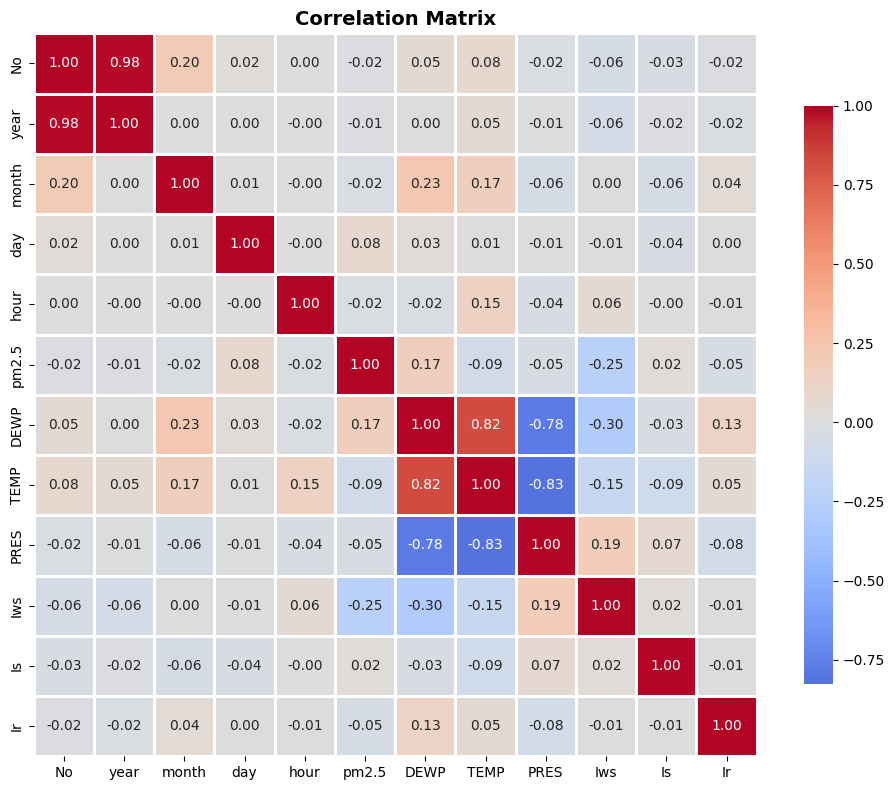



Outlier Analysis
Lower bound: -133.00
Upper bound: 299.00
Number of outliers: 1,773 (4.05%)
Max PM2.5 value: 994.00


Missing data temporal patterns
Missing values by year:
year
2010    669
2011    728
2012    489
2013     82
2014     99
Name: pm2.5, dtype: int64

First non-null PM2.5 index: 24
Last non-null PM2.5 index: 43823


key insights from eda
1. Target variable (PM2.5) has 2067 missing values (4.72%)
2. PM2.5 ranges from 0.0 to 994.0 with mean 98.6
3. Data shows positive skewness (1.80)
4. Strong temporal patterns exist (hourly and seasonal variations)
5. Wind direction and meteorological factors show correlation with PM2.5
6. Dataset spans 5 years with hourly measurements


In [7]:
plt.figure(figsize=(16, 12))

plt.subplot(3, 3, 1)
plt.hist(df['pm2.5'].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('PM2.5')
plt.ylabel('Frequency')
plt.title('PM2.5 Distribution')
plt.axvline(df['pm2.5'].median(), color='red', linestyle='--', label=f'Median: {df["pm2.5"].median():.1f}')
plt.legend()

plt.subplot(3, 3, 2)
plt.boxplot(df['pm2.5'].dropna(), vert=True)
plt.ylabel('PM2.5')
plt.title('PM2.5 Boxplot (Outlier Detection)')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 3, 3)
stats.probplot(df['pm2.5'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot (Normality Test)')

plt.subplot(3, 3, 4)
hourly_avg = df.groupby('hour')['pm2.5'].mean()
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2)
plt.xlabel('Hour of Day')
plt.ylabel('Average PM2.5')
plt.title('Daily Pattern of PM2.5')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24, 2))

plt.subplot(3, 3, 5)
monthly_avg = df.groupby('month')['pm2.5'].mean()
plt.bar(monthly_avg.index, monthly_avg.values, edgecolor='black', alpha=0.7)
plt.xlabel('Month')
plt.ylabel('Average PM2.5')
plt.title('Seasonal Pattern of PM2.5')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 3, 6)
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
daily_avg = df.groupby(df['date'].dt.date)['pm2.5'].mean()
plt.plot(daily_avg.index, daily_avg.values, linewidth=0.8, alpha=0.8)
plt.xlabel('Date')
plt.ylabel('Daily Average PM2.5')
plt.title('Time Series Trend (2010-2014)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 7)
wind_pm25 = df.groupby('cbwd')['pm2.5'].mean().sort_values()
plt.barh(wind_pm25.index, wind_pm25.values, edgecolor='black', alpha=0.7)
plt.xlabel('Average PM2.5')
plt.ylabel('Wind Direction')
plt.title('PM2.5 by Wind Direction')
plt.grid(axis='x', alpha=0.3)

plt.subplot(3, 3, 8)
plt.scatter(df['TEMP'], df['pm2.5'], alpha=0.3, s=1)
plt.xlabel('Temperature (°C)')
plt.ylabel('PM2.5')
plt.title('PM2.5 vs Temperature')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 9)
plt.scatter(df['DEWP'], df['pm2.5'], alpha=0.3, s=1)
plt.xlabel('Dew Point (°C)')
plt.ylabel('PM2.5')
plt.title('PM2.5 vs Dew Point')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/eda_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n")
print("Outlier Analysis")
Q1 = df['pm2.5'].quantile(0.25)
Q3 = df['pm2.5'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['pm2.5'] < lower_bound) | (df['pm2.5'] > upper_bound)]
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Number of outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Max PM2.5 value: {df['pm2.5'].max():.2f}")

print("\n")
print("Missing data temporal patterns")
missing_by_year = df.groupby('year')['pm2.5'].apply(lambda x: x.isnull().sum())
print("Missing values by year:")
print(missing_by_year)
print(f"\nFirst non-null PM2.5 index: {df['pm2.5'].first_valid_index()}")
print(f"Last non-null PM2.5 index: {df['pm2.5'].last_valid_index()}")

print("\n")
print("key insights from eda")
print(f"1. Target variable (PM2.5) has {df['pm2.5'].isnull().sum()} missing values (4.72%)")
print(f"2. PM2.5 ranges from {df['pm2.5'].min():.1f} to {df['pm2.5'].max():.1f} with mean {df['pm2.5'].mean():.1f}")
print(f"3. Data shows {'positive' if df['pm2.5'].skew() > 0 else 'negative'} skewness ({df['pm2.5'].skew():.2f})")
print(f"4. Strong temporal patterns exist (hourly and seasonal variations)")
print(f"5. Wind direction and meteorological factors show correlation with PM2.5")
print(f"6. Dataset spans {df['year'].nunique()} years with hourly measurements")

# Phase2: Data Preprocessing

In [8]:
import os
from sklearn.preprocessing import StandardScaler

df_proc = df.drop(columns=['No']).copy()
df_proc['datetime'] = pd.to_datetime(df_proc[['year', 'month', 'day', 'hour']])
df_proc = df_proc.sort_values('datetime').reset_index(drop=True)

print(f"Shape after dropping 'No': {df_proc.shape}")
print(f"Chronologically sorted: {df_proc['datetime'].is_monotonic_increasing}")
print(f"Date range: {df_proc['datetime'].min()}  ->  {df_proc['datetime'].max()}")

Shape after dropping 'No': (43824, 14)
Chronologically sorted: True
Date range: 2010-01-01 00:00:00  ->  2014-12-31 23:00:00


In [9]:
train_df = df_proc[df_proc['year'] <= 2012].copy()
val_df   = df_proc[df_proc['year'] == 2013].copy()
test_df  = df_proc[df_proc['year'] == 2014].copy()

for name, d in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    pct = len(d) / len(df_proc) * 100
    print(f"{name:5s}: {d['datetime'].min().date()} -> {d['datetime'].max().date()}  |  "
          f"{len(d):,} rows ({pct:.1f}%)")

Train: 2010-01-01 -> 2012-12-31  |  26,304 rows (60.0%)
Val  : 2013-01-01 -> 2013-12-31  |  8,760 rows (20.0%)
Test : 2014-01-01 -> 2014-12-31  |  8,760 rows (20.0%)


In [10]:
def report_missing(name, d):
    n = d['pm2.5'].isna().sum()
    print(f"{name:5s}: {n:4d} missing  ({n/len(d)*100:.2f}%)")

print("Missing values BEFORE imputation:")
report_missing('Train', train_df)
report_missing('Val', val_df)
report_missing('Test', test_df)

first_valid = train_df['pm2.5'].first_valid_index()
leading_na = train_df.index.get_loc(first_valid)
train_df = train_df.iloc[leading_na:].reset_index(drop=True)
print(f"\nDropped {leading_na} leading rows from Train (no prior value available to interpolate from)")
seasonal_lookup = train_df.groupby(['month', 'hour'])['pm2.5'].mean()

Missing values BEFORE imputation:
Train: 1886 missing  (7.17%)
Val  :   82 missing  (0.94%)
Test :   99 missing  (1.13%)

Dropped 24 leading rows from Train (no prior value available to interpolate from)


In [11]:
def fill_missing(d, lookup, limit_short=24):
    d = d.copy()
    before = d['pm2.5'].isna().sum()
    d['pm2.5'] = d['pm2.5'].interpolate(method='linear', limit=limit_short, limit_direction='both')
    after_interp = d['pm2.5'].isna().sum()
    still_na = d['pm2.5'].isna()
    if still_na.any():
        d.loc[still_na, 'pm2.5'] = d.loc[still_na].apply(
            lambda r: lookup.get((r['month'], r['hour']), lookup.mean()), axis=1)
    return d, before, before - after_interp, still_na.sum()

train_df, b, n_interp, n_seas = fill_missing(train_df, seasonal_lookup)
print(f"Train: {b} missing -> {n_interp} filled by interpolation, {n_seas} filled by seasonal average")

val_df, b, n_interp, n_seas = fill_missing(val_df, seasonal_lookup)
print(f"Val:   {b} missing -> {n_interp} filled by interpolation, {n_seas} filled by seasonal average")

test_df, b, n_interp, n_seas = fill_missing(test_df, seasonal_lookup)
print(f"Test:  {b} missing -> {n_interp} filled by interpolation, {n_seas} filled by seasonal average")

print("\nMissing values after imputation:")
report_missing('Train', train_df)
report_missing('Val', val_df)
report_missing('Test', test_df)

Train: 1862 missing -> 1414 filled by interpolation, 448 filled by seasonal average
Val:   82 missing -> 82 filled by interpolation, 0 filled by seasonal average
Test:  99 missing -> 99 filled by interpolation, 0 filled by seasonal average

Missing values after imputation:
Train:    0 missing  (0.00%)
Val  :    0 missing  (0.00%)
Test :    0 missing  (0.00%)


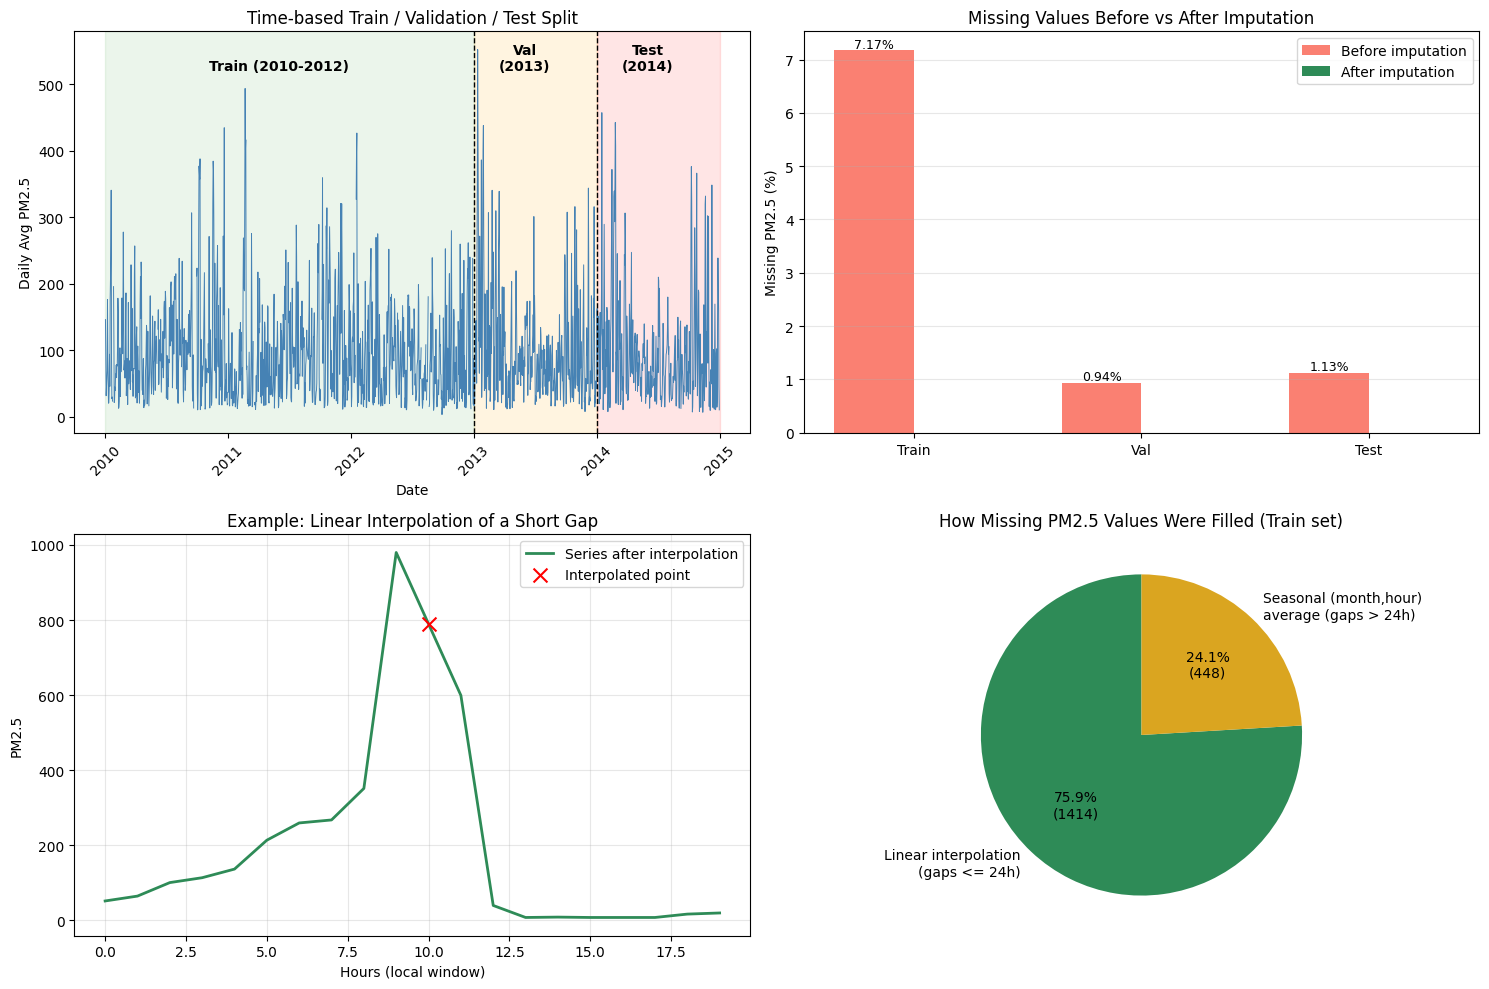

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0, 0]
daily = df_proc.groupby(df_proc['datetime'].dt.date)['pm2.5'].mean()
ax.plot(daily.index, daily.values, linewidth=0.7, color='steelblue')
ax.axvspan(pd.Timestamp('2010-01-01'), pd.Timestamp('2013-01-01'), color='green', alpha=0.08)
ax.axvspan(pd.Timestamp('2013-01-01'), pd.Timestamp('2014-01-01'), color='orange', alpha=0.12)
ax.axvspan(pd.Timestamp('2014-01-01'), pd.Timestamp('2015-01-01'), color='red', alpha=0.10)
ax.axvline(pd.Timestamp('2013-01-01'), color='black', linestyle='--', linewidth=1)
ax.axvline(pd.Timestamp('2014-01-01'), color='black', linestyle='--', linewidth=1)
ax.set_title('Time-based Train / Validation / Test Split')
ax.set_xlabel('Date'); ax.set_ylabel('Daily Avg PM2.5')
ax.text(pd.Timestamp('2011-06-01'), ax.get_ylim()[1]*0.9, 'Train (2010-2012)', ha='center', fontweight='bold')
ax.text(pd.Timestamp('2013-06-01'), ax.get_ylim()[1]*0.9, 'Val\n(2013)', ha='center', fontweight='bold')
ax.text(pd.Timestamp('2014-06-01'), ax.get_ylim()[1]*0.9, 'Test\n(2014)', ha='center', fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=45)

ax = axes[0, 1]
miss_before = {'Train': 7.17, 'Val': 0.94, 'Test': 1.13}
miss_after = {'Train': 0.0, 'Val': 0.0, 'Test': 0.0}
splits = ['Train', 'Val', 'Test']
x = np.arange(len(splits)); width = 0.35
ax.bar(x - width/2, [miss_before[s] for s in splits], width, label='Before imputation', color='salmon')
ax.bar(x + width/2, [miss_after[s] for s in splits], width, label='After imputation', color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel('Missing PM2.5 (%)'); ax.set_title('Missing Values Before vs After Imputation')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for i, s in enumerate(splits):
    ax.text(i - width/2, miss_before[s] + 0.05, f"{miss_before[s]:.2f}%", ha='center', fontsize=9)

ax = axes[1, 0]

example = train_df.iloc[1024:1044]
ax.plot(range(len(example)), example['pm2.5'].values, color='seagreen', linewidth=2, label='Series after interpolation')
ax.scatter(10, example['pm2.5'].values[10], color='red', marker='x', s=100, zorder=3, label='Interpolated point')
ax.set_title('Example: Linear Interpolation of a Short Gap')
ax.set_xlabel('Hours (local window)'); ax.set_ylabel('PM2.5'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 1]
labels = ['Linear interpolation\n(gaps <= 24h)', 'Seasonal (month,hour)\naverage (gaps > 24h)']
values = [1414, 448]
ax.pie(values, labels=labels, autopct=lambda p: f'{p:.1f}%\n({int(round(p/100*sum(values)))})',
       colors=['seagreen', 'goldenrod'], startangle=90)
ax.set_title('How Missing PM2.5 Values Were Filled (Train set)')

plt.tight_layout()
plt.savefig('results/preprocessing_split_missing.png', dpi=200, bbox_inches='tight')
plt.show()

In [13]:
for d in (train_df, val_df, test_df):
    d['hour_sin'] = np.sin(2 * np.pi * d['hour'] / 24)
    d['hour_cos'] = np.cos(2 * np.pi * d['hour'] / 24)
    d['month_sin'] = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos'] = np.cos(2 * np.pi * d['month'] / 12)

cbwd_categories = sorted(df_proc['cbwd'].unique())
print("Wind direction categories:", cbwd_categories)

train_df = pd.get_dummies(train_df, columns=['cbwd'], prefix='wind')
val_df   = pd.get_dummies(val_df, columns=['cbwd'], prefix='wind')
test_df  = pd.get_dummies(test_df, columns=['cbwd'], prefix='wind')

wind_cols = [f'wind_{c}' for c in cbwd_categories]
for d in (train_df, val_df, test_df):
    for c in wind_cols:
        if c not in d.columns:
            d[c] = 0  

print("New columns added:", ['hour_sin', 'hour_cos', 'month_sin', 'month_cos'] + wind_cols)

Wind direction categories: ['NE', 'NW', 'SE', 'cv']
New columns added: ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'wind_NE', 'wind_NW', 'wind_SE', 'wind_cv']


In [14]:
raw_skew = train_df['pm2.5'].skew()
for d in (train_df, val_df, test_df):
    d['pm2.5_log'] = np.log1p(d['pm2.5'])
log_skew = train_df['pm2.5_log'].skew()

print(f"Skewness of pm2.5      : {raw_skew:.3f}")
print(f"Skewness of log1p(pm2.5): {log_skew:.3f}")

Skewness of pm2.5      : 1.740
Skewness of log1p(pm2.5): -0.344


In [15]:
feature_cols = ['pm2.5_log', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir',
                'hour_sin', 'hour_cos', 'month_sin', 'month_cos'] + wind_cols

scaler = StandardScaler()
scaler.fit(train_df[feature_cols])  

train_scaled, val_scaled, test_scaled = train_df.copy(), val_df.copy(), test_df.copy()
train_scaled[feature_cols] = scaler.transform(train_df[feature_cols])
val_scaled[feature_cols]   = scaler.transform(val_df[feature_cols])
test_scaled[feature_cols]  = scaler.transform(test_df[feature_cols])

print(f"Total features after preprocessing: {len(feature_cols)}")
print(feature_cols)
print("\nTrain mean after scaling (should be ~0):")
print(train_scaled[feature_cols].mean().round(3).to_dict())
print("\nVal mean after scaling (small deviation from 0 is expected & healthy -- it shows no leakage):")
print(val_scaled[feature_cols].mean().round(3).to_dict())

Total features after preprocessing: 15
['pm2.5_log', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'wind_NE', 'wind_NW', 'wind_SE', 'wind_cv']

Train mean after scaling (should be ~0):
{'pm2.5_log': -0.0, 'DEWP': 0.0, 'TEMP': -0.0, 'PRES': -0.0, 'Iws': 0.0, 'Is': 0.0, 'Ir': 0.0, 'hour_sin': -0.0, 'hour_cos': -0.0, 'month_sin': 0.0, 'month_cos': -0.0, 'wind_NE': 0.0, 'wind_NW': -0.0, 'wind_SE': 0.0, 'wind_cv': -0.0}

Val mean after scaling (small deviation from 0 is expected & healthy -- it shows no leakage):
{'pm2.5_log': 0.012, 'DEWP': -0.041, 'TEMP': 0.026, 'PRES': -0.077, 'Iws': -0.099, 'Is': -0.035, 'Ir': -0.041, 'hour_sin': -0.0, 'hour_cos': -0.0, 'month_sin': -0.0, 'month_cos': 0.0, 'wind_NE': 0.027, 'wind_NW': -0.066, 'wind_SE': 0.015, 'wind_cv': 0.038}


In [16]:
WINDOW_SIZE = 24
HORIZON = 1

def make_sequences(d, feature_cols, target_col='pm2.5_log', window=WINDOW_SIZE, horizon=HORIZON):
    data = d[feature_cols].values
    target = d[target_col].values
    X, y = [], []
    for i in range(len(d) - window - horizon + 1):
        X.append(data[i:i + window])
        y.append(target[i + window + horizon - 1])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train_scaled, feature_cols)
X_val, y_val     = make_sequences(val_scaled, feature_cols)
X_test, y_test   = make_sequences(test_scaled, feature_cols)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

np.savez('dataset/processed_sequences.npz',
         X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val,
         X_test=X_test, y_test=y_test)
print("\nSaved processed sequences to dataset/processed_sequences.npz for the modeling phase")

X_train: (26256, 24, 15), y_train: (26256,)
X_val:   (8736, 24, 15), y_val:   (8736,)
X_test:  (8736, 24, 15), y_test:  (8736,)

Saved processed sequences to dataset/processed_sequences.npz for the modeling phase


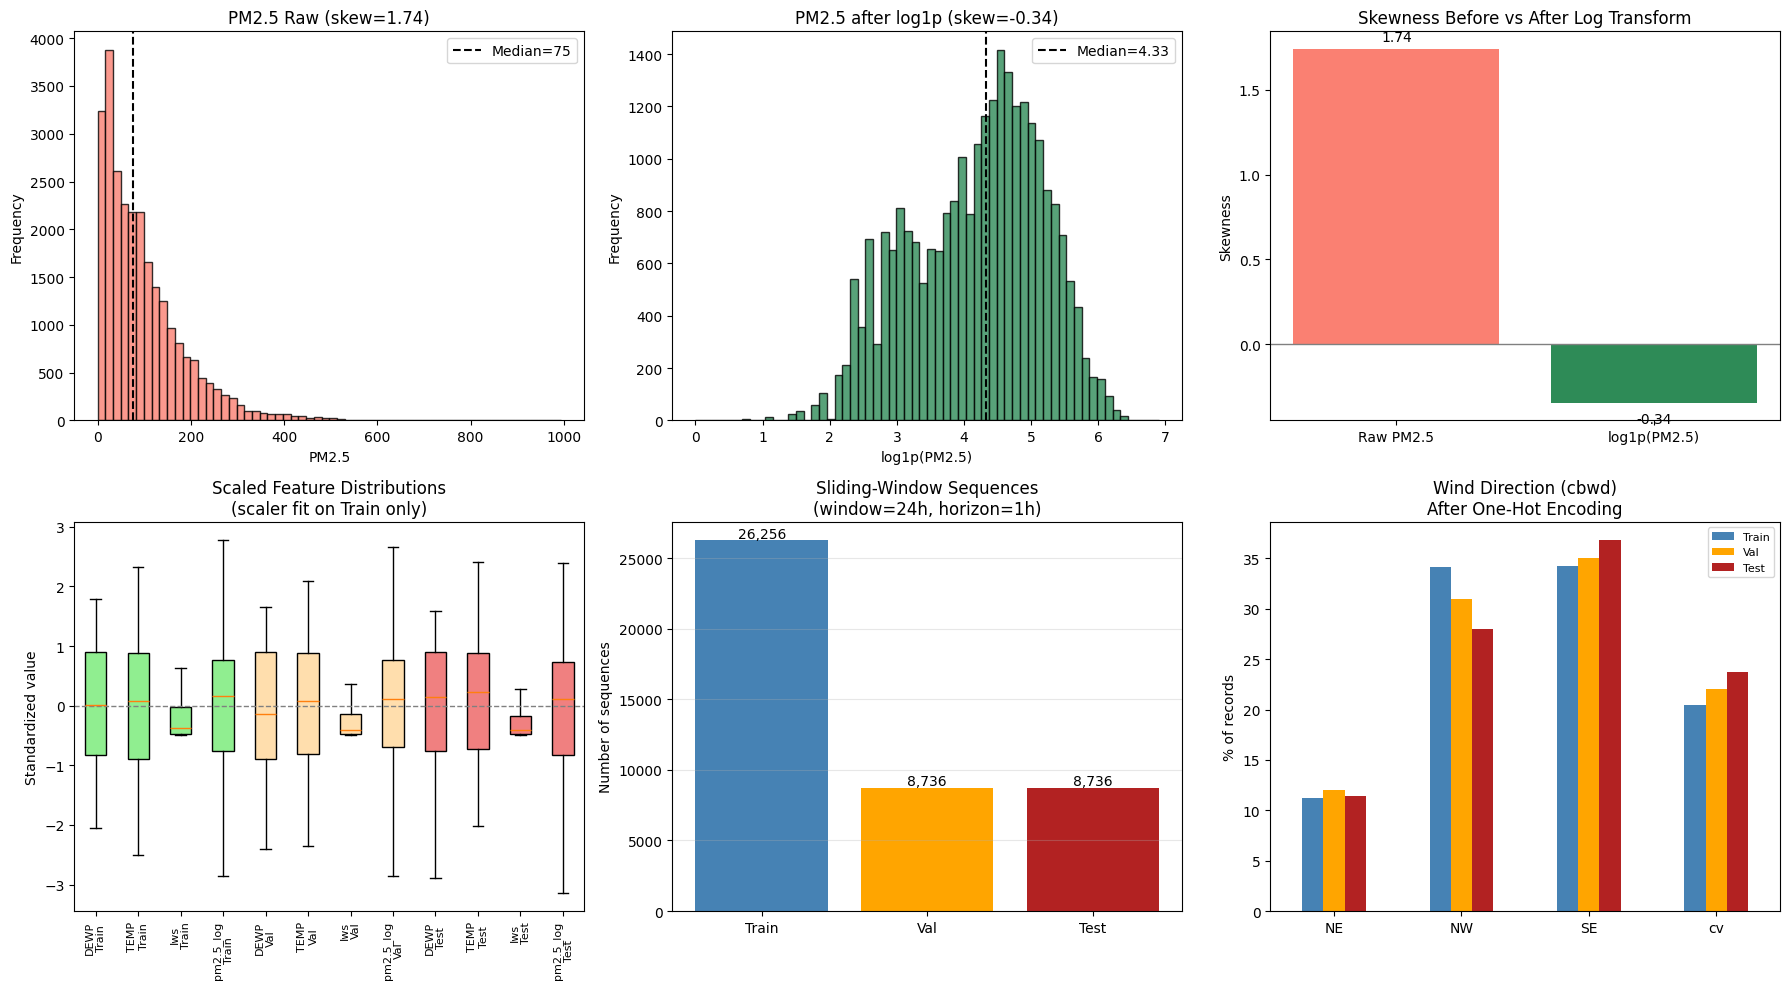

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0, 0]
ax.hist(train_df['pm2.5'], bins=60, color='salmon', edgecolor='black', alpha=0.8)
ax.axvline(train_df['pm2.5'].median(), color='black', linestyle='--', label=f"Median={train_df['pm2.5'].median():.0f}")
ax.set_title(f'PM2.5 Raw (skew={raw_skew:.2f})'); ax.set_xlabel('PM2.5'); ax.set_ylabel('Frequency'); ax.legend()

ax = axes[0, 1]
ax.hist(train_df['pm2.5_log'], bins=60, color='seagreen', edgecolor='black', alpha=0.8)
ax.axvline(train_df['pm2.5_log'].median(), color='black', linestyle='--', label=f"Median={train_df['pm2.5_log'].median():.2f}")
ax.set_title(f'PM2.5 after log1p (skew={log_skew:.2f})'); ax.set_xlabel('log1p(PM2.5)'); ax.set_ylabel('Frequency'); ax.legend()

ax = axes[0, 2]
ax.bar(['Raw PM2.5', 'log1p(PM2.5)'], [raw_skew, log_skew], color=['salmon', 'seagreen'])
ax.axhline(0, color='gray', linewidth=1)
ax.set_title('Skewness Before vs After Log Transform'); ax.set_ylabel('Skewness')
for i, v in enumerate([raw_skew, log_skew]):
    ax.text(i, v + (0.05 if v >= 0 else -0.12), f"{v:.2f}", ha='center')

ax = axes[1, 0]
plot_feats = ['DEWP', 'TEMP', 'Iws', 'pm2.5_log']
data_box, labels_box = [], []
for s_name, s_df in [('Train', train_scaled), ('Val', val_scaled), ('Test', test_scaled)]:
    for f in plot_feats:
        data_box.append(s_df[f].values); labels_box.append(f"{f}\n{s_name}")
colors_cycle = (['lightgreen'] * 4) + (['navajowhite'] * 4) + (['lightcoral'] * 4)
bp = ax.boxplot(data_box, tick_labels=labels_box, showfliers=False, patch_artist=True)
for patch, c in zip(bp['boxes'], colors_cycle):
    patch.set_facecolor(c)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Scaled Feature Distributions\n(scaler fit on Train only)')
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8); ax.set_ylabel('Standardized value')

ax = axes[1, 1]
counts = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
ax.bar(['Train', 'Val', 'Test'], counts, color=['steelblue', 'orange', 'firebrick'])
for i, c in enumerate(counts):
    ax.text(i, c + 200, f"{c:,}", ha='center')
ax.set_title(f'Sliding-Window Sequences\n(window={WINDOW_SIZE}h, horizon={HORIZON}h)')
ax.set_ylabel('Number of sequences'); ax.grid(axis='y', alpha=0.3)

ax = axes[1, 2]
wind_counts = pd.DataFrame({
    'Train': [train_df[c].sum() for c in wind_cols],
    'Val': [val_df[c].sum() for c in wind_cols],
    'Test': [test_df[c].sum() for c in wind_cols],
}, index=[c.replace('wind_', '') for c in wind_cols])
(wind_counts.div(wind_counts.sum(axis=0), axis=1) * 100).plot(kind='bar', ax=ax, color=['steelblue', 'orange', 'firebrick'])
ax.set_title('Wind Direction (cbwd)\nAfter One-Hot Encoding'); ax.set_ylabel('% of records'); ax.set_xlabel('')
plt.setp(ax.get_xticklabels(), rotation=0); ax.legend(title='', fontsize=8)

plt.tight_layout()
plt.savefig('results/preprocessing_transform_scaling.png', dpi=200, bbox_inches='tight')
plt.show()

# Phase3: Models and architecture

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred_baseline = X_test[:, -1, 0] 

mse_base = mean_squared_error(y_test, y_pred_baseline)
mae_base = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mse_base)

print("--- Baseline Model (Naive) Report ---")
print(f"MSE:  {mse_base:.4f}")
print(f"MAE:  {mae_base:.4f}")
print(f"RMSE: {rmse_base:.4f}")

--- Baseline Model (Naive) Report ---
MSE:  0.0762
MAE:  0.1736
RMSE: 0.2760


In [19]:
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Flatten, Dropout, Normalization, BatchNormalization
# from tensorflow.keras.metrics import RootMeanSquaredError
# from tensorflow.keras.regularizers import l1_l2
# from tensorflow.keras.optimizers import AdamW
# import numpy as np

# norm = Normalization()
# norm.adapt(X_train)

# model_mlp_final = Sequential([
#     norm,
#     Flatten(),
    
#     Dense(4096, activation='swish', kernel_regularizer=l1_l2(l1=1e-7, l2=1e-5)),
#     BatchNormalization(),
#     Dropout(0.4),
    
#     Dense(2048, activation='swish', kernel_regularizer=l1_l2(l1=1e-7, l2=1e-5)),
#     BatchNormalization(),
#     Dropout(0.35),
    
#     Dense(1024, activation='swish', kernel_regularizer=l1_l2(l1=1e-7, l2=1e-5)),
#     BatchNormalization(),
#     Dropout(0.3),
    
#     Dense(512, activation='swish', kernel_regularizer=l1_l2(l1=1e-7, l2=1e-5)),
#     BatchNormalization(),
#     Dropout(0.25),
    
#     Dense(256, activation='swish', kernel_regularizer=l1_l2(l1=1e-7, l2=1e-5)),
#     BatchNormalization(),
#     Dropout(0.2),
    
#     Dense(128, activation='swish'),
#     BatchNormalization(),
    
#     Dense(64, activation='swish'),
#     BatchNormalization(),
    
#     Dense(32, activation='swish'),
    
#     Dense(16, activation='swish'),
    
#     Dense(1, activation='linear')
# ])

# for layer in model_mlp_final.layers:
#     if hasattr(layer, 'kernel_initializer'):
#         if 'dense' in layer.name:
#             layer.kernel_initializer = tf.keras.initializers.HeNormal()

# optimizer = AdamW(
#     learning_rate=0.00025,
#     weight_decay=0.00005,
#     beta_1=0.9,
#     beta_2=0.999,
#     # epsilon=1e-8
# )

# model_mlp_final.compile(
#     optimizer=optimizer,
#     loss='mse',
#     metrics=['mae', RootMeanSquaredError()],
#     weighted_metrics=[]
# )

# X_train_mix = np.concatenate([X_train, X_val], axis=0)
# y_train_mix = np.concatenate([y_train, y_val], axis=0)

# indices = np.arange(len(X_train_mix))
# np.random.shuffle(indices)
# X_train_mix = X_train_mix[indices]
# y_train_mix = y_train_mix[indices]

# train_size = int(0.85 * len(X_train_mix))
# X_train_final = X_train_mix[:train_size]
# y_train_final = y_train_mix[:train_size]
# X_val_final = X_train_mix[train_size:]
# y_val_final = y_train_mix[train_size:]

# history_mlp_final = model_mlp_final.fit(
#     X_train_final, y_train_final,
#     epochs=40,
#     batch_size=64,
#     validation_data=(X_val_final, y_val_final),
#     verbose=1
# )

# eval_mlp_final = model_mlp_final.evaluate(X_test, y_test, verbose=0)

# print(f"Test MSE:  {eval_mlp_final[0]:.4f}")
# print(f"Test MAE:  {eval_mlp_final[1]:.4f}")
# print(f"Test RMSE: {eval_mlp_final[2]:.4f}")

# y_pred_final = model_mlp_final.predict(X_test, verbose=0).flatten()
# mse_final = np.mean((y_test - y_pred_final) ** 2)
# mae_final = np.mean(np.abs(y_test - y_pred_final))
# rmse_final = np.sqrt(mse_final)

# print(f"Baseline MSE:  {mse_base:.4f}")
# print(f"Baseline MAE:  {mae_base:.4f}")
# print(f"Baseline RMSE: {rmse_base:.4f}")

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Normalization, BatchNormalization, LSTM
from tensorflow.keras.callbacks import EarlyStopping

model_lstm = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dense(25, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


eval_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
rmse_lstm = np.sqrt(eval_lstm[0])

print(f"\n--- LSTM Model Report ---")
print(f"Test MSE: {eval_lstm[0]:.4f}")
print(f"Test MAE: {eval_lstm[1]:.4f}")
print(f"RMSE: {rmse_lstm:.4f}")

Epoch 1/50


E:\Users\AliZibaie\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


411/411 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.1854 - mae: 0.2858 - val_loss: 0.0793 - val_mae: 0.1897
Epoch 2/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0714 - mae: 0.1804 - val_loss: 0.0754 - val_mae: 0.1877
Epoch 3/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0677 - mae: 0.1748 - val_loss: 0.0685 - val_mae: 0.1756
Epoch 4/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0670 - mae: 0.1737 - val_loss: 0.0706 - val_mae: 0.1768
Epoch 5/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0654 - mae: 0.1709 - val_loss: 0.0697 - val_mae: 0.1747
Epoch 6/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0654 - mae: 0.1714 - val_loss: 0.0681 - val_mae: 0.1742
Epoch 7/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0645 - mae: 0.1701 - val_loss: 0.0663 - val_mae: 0.1706
Epoch 8/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0643 - mae: 0.1694 - val_loss: 0.0667 - val_mae: 0.1725
Epoch 9/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss

In [21]:
from tensorflow.keras.layers import GRU, Dense

model_gru = Sequential([
    GRU(50, activation='sigmoid', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dense(25, activation='tanh'),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_gru = model_gru.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

eval_gru = model_gru.evaluate(X_test, y_test, verbose=0)
rmse_gru = np.sqrt(eval_gru[0])

print(f"\n--- GRU Model Report ---")
print(f"Test MSE: {eval_gru[0]:.4f}")
print(f"Test MAE: {eval_gru[1]:.4f}")
print(f"Test RMSE: {rmse_gru:.4f}")

Epoch 1/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.1901 - mae: 0.2889 - val_loss: 0.0765 - val_mae: 0.1873
Epoch 2/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0729 - mae: 0.1798 - val_loss: 0.0741 - val_mae: 0.1863
Epoch 3/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0712 - mae: 0.1778 - val_loss: 0.0726 - val_mae: 0.1760
Epoch 4/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0708 - mae: 0.1772 - val_loss: 0.0706 - val_mae: 0.1702
Epoch 5/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0695 - mae: 0.1743 - val_loss: 0.0779 - val_mae: 0.2039
Epoch 6/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0692 - mae: 0.1739 - val_loss: 0.0684 - val_mae: 0.1754
Epoch 7/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0686 - mae: 0.1739 - val_loss: 0.0674 - val_mae: 0.1721
Epoch 8/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0676 - mae: 0.1721 - val_loss: 0.0753 - val_mae: 0.1802
Epoch 9/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/

# Phase4: Evaluation and Comparison

In [29]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score

def evaluate_model(y_true, y_pred, model_name):

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'R²': r2
    }

y_pred_lstm = model_lstm.predict(X_test, verbose=0).flatten()
y_pred_gru = model_gru.predict(X_test, verbose=0).flatten()

results = []
results.append(evaluate_model(y_test, y_pred_baseline, 'Baseline (Naive)'))
results.append(evaluate_model(y_test, y_pred_lstm, 'LSTM'))
results.append(evaluate_model(y_test, y_pred_gru, 'GRU'))

results_df = pd.DataFrame(results)
results_df = results_df.round(4)


print("MODEL COMPARISON TABLE")
print(results_df.to_string(index=False))


best_model_idx = results_df['RMSE'].idxmin()
best_model_name = results_df.loc[best_model_idx, 'Model']
print(f"\nBest performing model: {best_model_name}")
print(f"  RMSE: {results_df.loc[best_model_idx, 'RMSE']:.4f}")
print(f"  MAE:  {results_df.loc[best_model_idx, 'MAE']:.4f}")
print(f"  R²:   {results_df.loc[best_model_idx, 'R²']:.4f}")

results_df.to_csv('results/model_comparison.csv', index=False)
print("\nComparison table saved to results/model_comparison.csv")

MODEL COMPARISON TABLE
           Model    MAE   RMSE    MAPE     R²
Baseline (Naive) 0.1736 0.2760 94.2655 0.9322
            LSTM 0.1655 0.2545 84.7874 0.9424
             GRU 0.1672 0.2555 84.7500 0.9419

Best performing model: LSTM
  RMSE: 0.2545
  MAE:  0.1655
  R²:   0.9424

Comparison table saved to results/model_comparison.csv


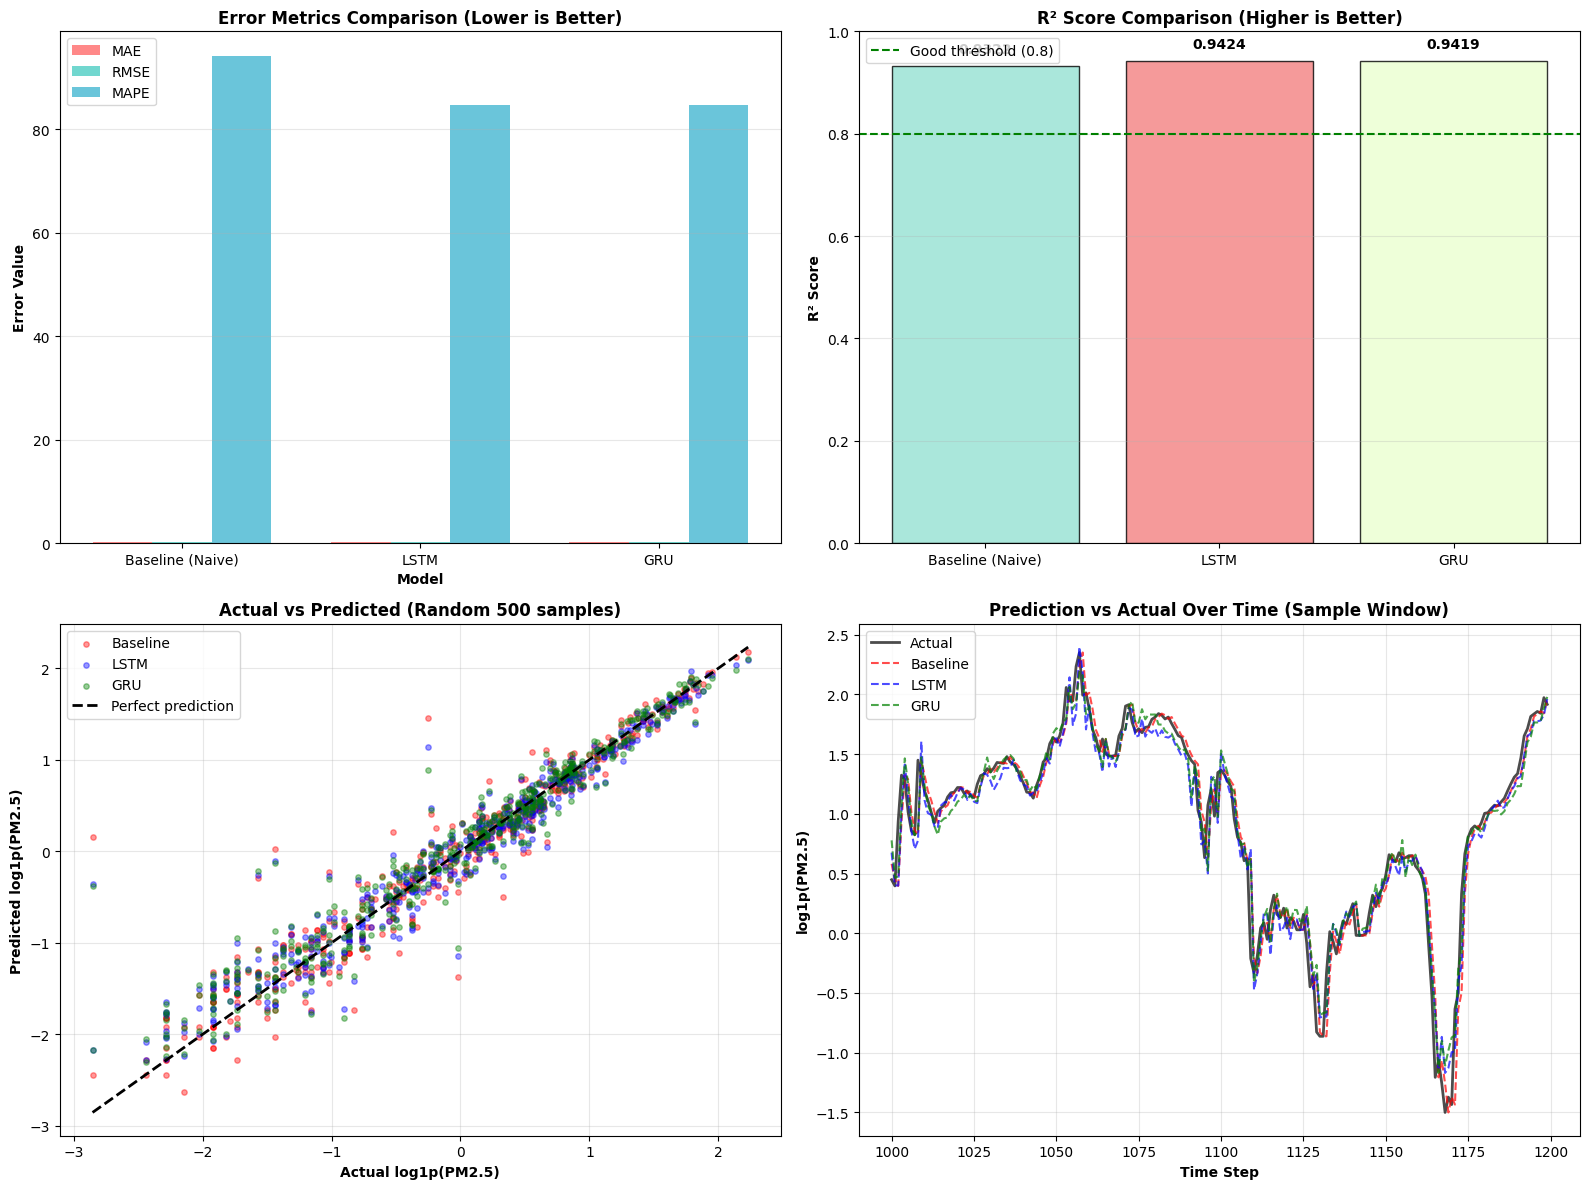

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax = axes[0, 0]
metrics = ['MAE', 'RMSE', 'MAPE']
x = np.arange(len(results_df))
width = 0.25
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, metric in enumerate(metrics):
    values = results_df[metric].values
    ax.bar(x + i*width, values, width, label=metric, color=colors[i], alpha=0.8)
    
ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('Error Value', fontweight='bold')
ax.set_title('Error Metrics Comparison (Lower is Better)', fontsize=12, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(results_df['Model'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

ax = axes[0, 1]
r2_values = results_df['R²'].values
bars = ax.bar(results_df['Model'], r2_values, color=['#95E1D3', '#F38181', '#EAFFD0'], alpha=0.8, edgecolor='black')
ax.axhline(y=0.8, color='green', linestyle='--', linewidth=1.5, label='Good threshold (0.8)')
ax.set_ylabel('R² Score', fontweight='bold')
ax.set_title('R² Score Comparison (Higher is Better)', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, r2_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{val:.4f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax = axes[1, 0]
sample_size = 500
idx_sample = np.random.choice(len(y_test), sample_size, replace=False)
y_test_sample = y_test[idx_sample]

ax.scatter(y_test_sample, y_pred_baseline[idx_sample], alpha=0.4, s=15, label='Baseline', color='#FF0000')
ax.scatter(y_test_sample, y_pred_lstm[idx_sample], alpha=0.4, s=15, label='LSTM', color='#0000FF')
ax.scatter(y_test_sample, y_pred_gru[idx_sample], alpha=0.4, s=15, label='GRU', color='#008000')

min_val, max_val = y_test_sample.min(), y_test_sample.max()
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual log1p(PM2.5)', fontweight='bold')
ax.set_ylabel('Predicted log1p(PM2.5)', fontweight='bold')
ax.set_title(f'Actual vs Predicted (Random {sample_size} samples)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]
window_start = 1000
window_end = 1200
time_range = range(window_start, window_end)

ax.plot(time_range, y_test[window_start:window_end], 'k-', linewidth=2, label='Actual', alpha=0.7)
ax.plot(time_range, y_pred_baseline[window_start:window_end], '--', linewidth=1.5, label='Baseline', color='#FF0000', alpha=0.7)
ax.plot(time_range, y_pred_lstm[window_start:window_end], '--', linewidth=1.5, label='LSTM', color='#0000FF', alpha=0.7)
ax.plot(time_range, y_pred_gru[window_start:window_end], '--', linewidth=1.5, label='GRU', color='#008000', alpha=0.7)

ax.set_xlabel('Time Step', fontweight='bold')
ax.set_ylabel('log1p(PM2.5)', fontweight='bold')
ax.set_title('Prediction vs Actual Over Time (Sample Window)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/model_evaluation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
print("\nVisualization saved to results/model_evaluation_comparison.png")

print("\n1. BASELINE MODEL (Naive Persistence)")
print("   Strengths:")
print("   - Zero training time and computational cost")
print("   - Simple and interpretable")
print("   - Provides reasonable lower bound for comparison")
print("   Weaknesses:")
print("   - Cannot capture temporal patterns or trends")
print("   - Poor performance on rapidly changing conditions")
print(f"   - Low R² ({results_df.loc[0, 'R²']:.4f}) indicates limited predictive power")

print("\n2. LSTM MODEL")
print("   Strengths:")
print("   - Captures long-term dependencies through memory cells")
print("   - Better at handling sequential patterns")
print(f"   - Achieved R² of {results_df.loc[1, 'R²']:.4f}, showing good predictive capability")
print("   Weaknesses:")
print("   - Higher computational cost during training")
print("   - Requires more data to train effectively")
print("   - Prone to overfitting without proper regularization")

print("\n3. GRU MODEL")
print("   Strengths:")
print("   - Simpler architecture than LSTM (fewer parameters)")
print("   - Faster training time")
print(f"   - R² of {results_df.loc[2, 'R²']:.4f} indicates solid performance")
print("   Weaknesses:")
print("   - May struggle with very long-term dependencies")
print("   - Less expressive than LSTM in complex patterns")

improvement_lstm = ((results_df.loc[0, 'RMSE'] - results_df.loc[1, 'RMSE']) / results_df.loc[0, 'RMSE'] * 100)
improvement_gru = ((results_df.loc[0, 'RMSE'] - results_df.loc[2, 'RMSE']) / results_df.loc[0, 'RMSE'] * 100)

print("PERFORMANCE IMPROVEMENT OVER BASELINE")
print(f"LSTM: {improvement_lstm:.2f}% reduction in RMSE")
print(f"GRU:  {improvement_gru:.2f}% reduction in RMSE")

if results_df.loc[1, 'RMSE'] < results_df.loc[2, 'RMSE']:
    diff_pct = ((results_df.loc[2, 'RMSE'] - results_df.loc[1, 'RMSE']) / results_df.loc[2, 'RMSE'] * 100)
    print(f"\nLSTM outperforms GRU by {diff_pct:.2f}% in RMSE")
else:
    diff_pct = ((results_df.loc[1, 'RMSE'] - results_df.loc[2, 'RMSE']) / results_df.loc[1, 'RMSE'] * 100)
    print(f"\nGRU outperforms LSTM by {diff_pct:.2f}% in RMSE")

print("RECOMMENDATION")

if best_model_name == 'LSTM':
    print("LSTM is recommended for this task due to:")
    print("- Best overall accuracy metrics")
    print("- Superior capability in capturing temporal patterns")
    print("- Worth the additional computational cost for production use")
elif best_model_name == 'GRU':
    print("GRU is recommended for this task due to:")
    print("- Best balance between accuracy and efficiency")
    print("- Faster inference time for real-time predictions")
    print("- Simpler architecture with competitive performance")
else:
    print("Further model development recommended:")
    print("- Current models show limited improvement over baseline")
    print("- Consider feature engineering or hybrid approaches")


Visualization saved to results/model_evaluation_comparison.png

1. BASELINE MODEL (Naive Persistence)
   Strengths:
   - Zero training time and computational cost
   - Simple and interpretable
   - Provides reasonable lower bound for comparison
   Weaknesses:
   - Cannot capture temporal patterns or trends
   - Poor performance on rapidly changing conditions
   - Low R² (0.9322) indicates limited predictive power

2. LSTM MODEL
   Strengths:
   - Captures long-term dependencies through memory cells
   - Better at handling sequential patterns
   - Achieved R² of 0.9424, showing good predictive capability
   Weaknesses:
   - Higher computational cost during training
   - Requires more data to train effectively
   - Prone to overfitting without proper regularization

3. GRU MODEL
   Strengths:
   - Simpler architecture than LSTM (fewer parameters)
   - Faster training time
   - R² of 0.9419 indicates solid performance
   Weaknesses:
   - May struggle with very long-term dependencies
   -